<a href="https://colab.research.google.com/github/arbazshah52/Lektion1/blob/main/linj%C3%A4r_regression_exempel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression - Example
In this notebook we demonstrate a Machine Learning workflow using a train, validation and test set.

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import load_diabetes

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Loading Data

In [20]:
# This code is merely executed to make it easy to inspect the dataset description
diabetes = load_diabetes()

In [21]:
# print(diabetes.DESCR)

## Storing/Loading the data in the way it will be used

In [22]:
X, y = load_diabetes(return_X_y=True, as_frame=True)

# Only choose two variables for our models
X = X[['bmi', 'bp']]

# Give the target a descriptive name
y.name = 'disease_progression'

In [23]:
print(X.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   bmi     442 non-null    float64
 1   bp      442 non-null    float64
dtypes: float64(2)
memory usage: 7.0 KB
None


In [24]:
print(y.info())

<class 'pandas.core.series.Series'>
RangeIndex: 442 entries, 0 to 441
Series name: disease_progression
Non-Null Count  Dtype  
--------------  -----  
442 non-null    float64
dtypes: float64(1)
memory usage: 3.6 KB
None


# Train, Validation, and Test Set

In [25]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.3, random_state=36)

# EDA
We are only allowed to explore and learn things from the training data when creating our model.

Text(0.5, 1.0, 'Blood pressure vs. target (Train Data)')

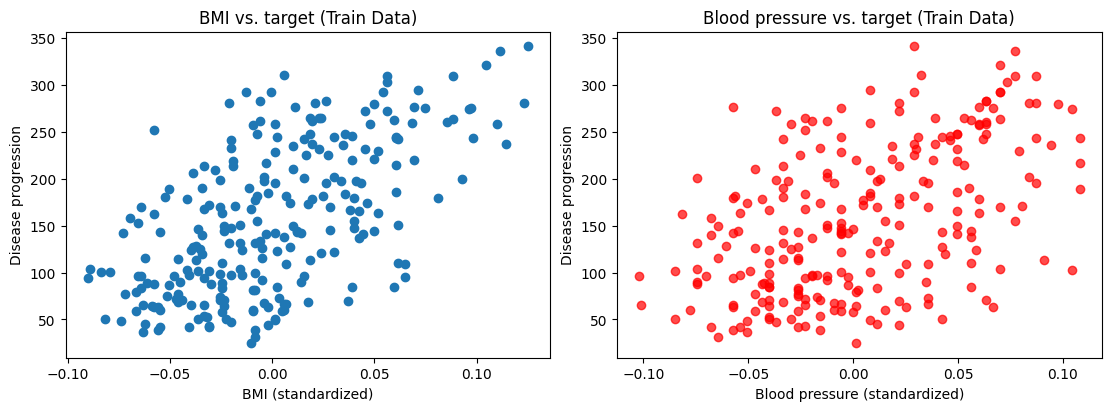

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4), layout='constrained')

axs[0].scatter(X_train['bmi'], y_train)
axs[0].set_xlabel('BMI (standardized)')
axs[0].set_ylabel('Disease progression')
axs[0].set_title('BMI vs. target (Train Data)')

axs[1].scatter(X_train['bp'], y_train, alpha=0.7, color='red')
axs[1].set_xlabel('Blood pressure (standardized)')
axs[1].set_ylabel('Disease progression')
axs[1].set_title('Blood pressure vs. target (Train Data)')

In [27]:
X_train.head()

,bmi,bp
164,-0.019140,0.021872
364,-0.006206,-0.019442
257,-0.055785,0.025315
355,-0.009439,0.014987
99,-0.064408,0.011544


In [28]:
y_train.head()

,disease_progression
164,214.0
364,262.0
257,63.0
355,60.0
99,83.0


In [29]:
y_train.describe()

,disease_progression
count,247.000000
mean,156.514170
std,78.239306
min,25.000000
25%,89.000000
50%,146.000000
75%,220.500000
max,341.000000


### Distributions of Features and Target in Training Data

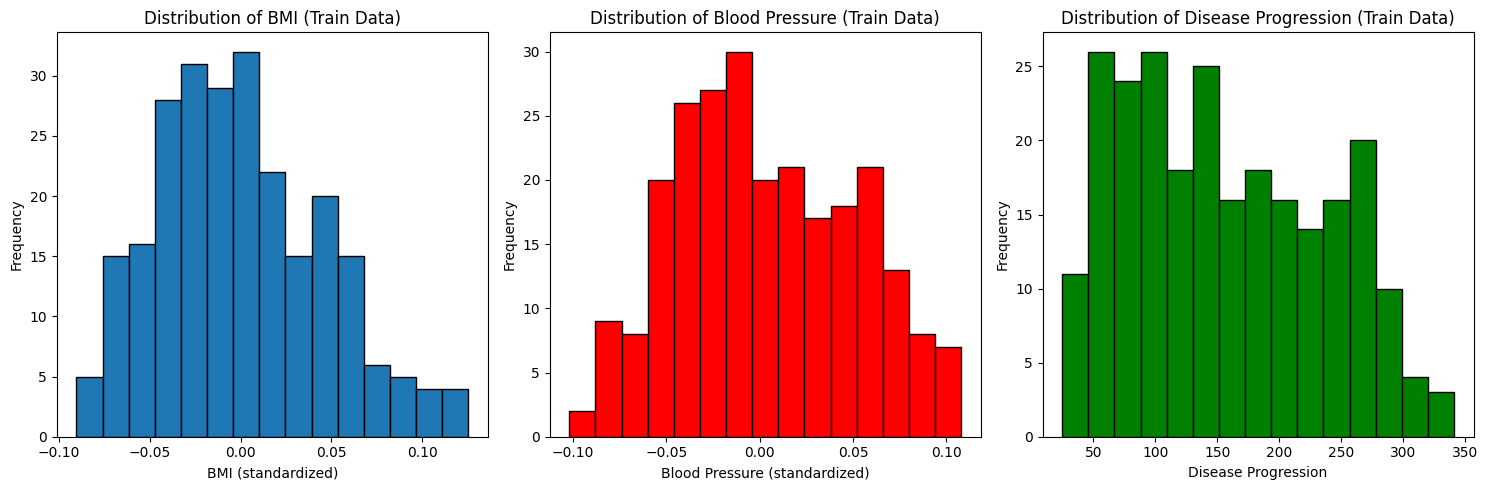

In [37]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].hist(X_train['bmi'], bins=15, edgecolor='black')
axs[0].set_title('Distribution of BMI (Train Data)')
axs[0].set_xlabel('BMI (standardized)')
axs[0].set_ylabel('Frequency')

axs[1].hist(X_train['bp'], bins=15, edgecolor='black', color='red')
axs[1].set_title('Distribution of Blood Pressure (Train Data)')
axs[1].set_xlabel('Blood Pressure (standardized)')
axs[1].set_ylabel('Frequency')

axs[2].hist(y_train, bins=15, edgecolor='black', color='green')
axs[2].set_title('Distribution of Disease Progression (Train Data)')
axs[2].set_xlabel('Disease Progression')
axs[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Correlation Matrix

In [38]:
train_data_for_corr = X_train.copy()
train_data_for_corr['disease_progression'] = y_train

correlation_matrix = train_data_for_corr.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Train Data)')
plt.show()

NameError: name 'sns' is not defined

<Figure size 600x500 with 0 Axes>

# Training 2 different models

In [30]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
lin_reg_pred = lin_reg.predict(X_val)

In [31]:
tree_reg = DecisionTreeRegressor(random_state=42)

# Find the best hyperparameter through GridSearch.
hyper_params = {'max_depth': (None, 1, 2, 3, 5, 10)}
reg = GridSearchCV(
    tree_reg,
    hyper_params,
    scoring='neg_root_mean_squared_error',
    cv=5
)

reg.fit(X_train, y_train)
tree_reg_pred = reg.predict(X_val)

In [32]:
print(reg.best_params_)
pd.DataFrame(reg.cv_results_)

{'max_depth': 3}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.003179,0.000873,0.001745,0.000300,None,{'max_depth': None},-78.867357,-84.035409,-90.569316,-89.015276,-86.981818,-85.893835,4.137931,6
1,0.002316,0.000244,0.001601,0.000065,1,{'max_depth': 1},-65.605783,-61.425230,-80.568091,-64.249342,-65.264180,-67.422525,6.735006,3
2,0.002161,0.000038,0.001466,0.000022,2,{'max_depth': 2},-66.056052,-58.730393,-77.212353,-63.078433,-71.048691,-67.225184,6.404477,2
3,0.002195,0.000053,0.001450,0.000006,3,{'max_depth': 3},-61.788878,-59.177680,-78.992051,-61.376213,-71.768824,-66.620729,7.560466,1
4,0.002279,0.000115,0.001437,0.000007,5,{'max_depth': 5},-68.560433,-58.462729,-80.243989,-69.766730,-74.687382,-70.344253,7.232617,4
5,0.002453,0.000020,0.001463,0.000038,10,{'max_depth': 10},-75.808369,-79.514153,-83.585147,-90.663146,-80.443883,-82.002939,4.989990,5


## Choosing the best model through validation set
For MAE and RMSE, lower is better. We use RMSE as the primary metric for choosing a model.

In [33]:
def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred))
    }

validation_results = pd.DataFrame({
    'Linear Regression': regression_metrics(y_val, lin_reg_pred),
    'Decision Tree': regression_metrics(y_val, tree_reg_pred)
}).T

validation_results

,MAE,RMSE
Linear Regression,45.376890,55.737794
Decision Tree,44.610292,56.599319


Text(0.5, 1.0, 'Decision Tree')

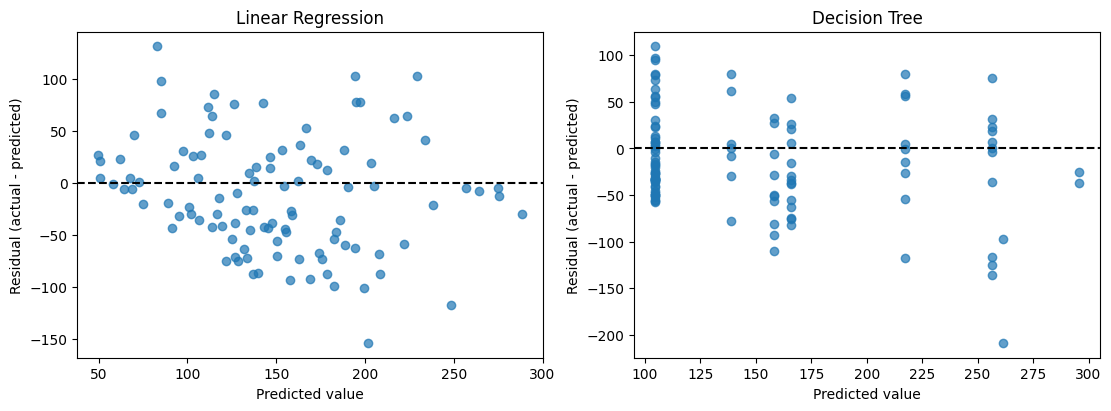

In [34]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4), layout='constrained')

# Linear regression
lin_reg_residuals = y_val - lin_reg_pred

axs[0].scatter(lin_reg_pred, lin_reg_residuals, alpha=0.7)
axs[0].axhline(0, color='black', linestyle='--')
axs[0].set_xlabel('Predicted value')
axs[0].set_ylabel('Residual (actual - predicted)')
axs[0].set_title('Linear Regression')

# Decision tree
tree_reg_residuals = y_val - tree_reg_pred

axs[1].scatter(tree_reg_pred, tree_reg_residuals, alpha=0.7)
axs[1].axhline(0, color='black', linestyle='--')
axs[1].set_xlabel('Predicted value')
axs[1].set_ylabel('Residual (actual - predicted)')
axs[1].set_title('Decision Tree')

# Evaluating chosen model through test set
The linear regression model has the lower validation RMSE for this split, so we choose it. We now retrain it using the combined training and validation data, then evaluate it once on the untouched test set.

**Question: What is the purpose with test data?**

In [35]:
# Now we retrain our chosen model on the train + validation data.
lin_reg_final = LinearRegression().fit(X_train_full, y_train_full)
pred_test = lin_reg_final.predict(X_test)

In [36]:
test_results = pd.Series(
    regression_metrics(y_test, pred_test),
    name='Test set'
)
test_results

,Test set
MAE,54.725429
RMSE,66.405554


In [40]:
print(X_val.head(1))

          bmi        bp
252  0.059541 -0.056177


In [41]:
print(lin_reg.predict(X_val)[1])

113.96317200931011


The value printed above is the predicted disease progression for the second sample in your validation set, based on the linear regression model.

In [42]:
print(y_val.head(1))

252    91.0
Name: disease_progression, dtype: float64


This shows the actual disease progression value for the first sample in the validation set (`y_val`). Comparing this with `lin_reg.predict(X_val)[0]` (which would be the prediction for the first sample) would give you the residual for that specific data point.